In [13]:
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import pathlib
import subprocess
import tempfile
import shutil
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

In [14]:
# ── edit these ────────────────────────────────────────────────────────────
notes = "second primary test"

foldername_date = "20260604"
foldername      = "newprimaryagain"
rootpath = pathlib.Path(
    "C:/Users/jad507/OneDrive - The Pennsylvania State University/Pictures/Reverse Telescope Test"
)

VIDEO_FPS       = 24    # output video frame rate
SECONDS_PER_DAY = 15    # video seconds per real day
FWHM_MIN        = 1     # px  -- reject fits narrower than this
FWHM_MAX        = 500   # px  -- reject fits wider than this
WORKERS         = 16    # parallel threads for fitting
filepath        = rootpath / (foldername_date + "_data") / foldername
# output_dir      = pathlib.Path("C:/Users/jad507/OneDrive - The Pennsylvania State University/Pictures/Reverse Telescope Test/20260420_data/zoeysecondarygenie/run2/")  # set a pathlib.Path to redirect outputs; None = save alongside data
output_dir = filepath
# ─────────────────────────────────────────────────────────────────────────

In [15]:
filepath        = rootpath / (foldername_date + "_data") / foldername
folderpath_date = rootpath / (foldername_date + "_data")
fits_glob       = str(filepath / (foldername + "_fits") / "*.fits")

fits_list = sorted(glob.glob(fits_glob))
assert fits_list, f"No FITS files found: {fits_glob}"
print(f"Found {len(fits_list)} files")

# timelapse_j.m fires every 60 s  ->  1440 frames / day
# video target: VIDEO_FPS * SECONDS_PER_DAY frames per day
FRAMES_PER_DAY_REAL  = 60 * 24
FRAMES_PER_DAY_VIDEO = VIDEO_FPS * SECONDS_PER_DAY
N_SKIP  = max(1, round(FRAMES_PER_DAY_REAL / FRAMES_PER_DAY_VIDEO))
n_video = len(fits_list) // N_SKIP
print(f"N_SKIP = {N_SKIP}  ->  ~{n_video} video frames  ->  ~{n_video / VIDEO_FPS:.0f}s video")
output_dir = output_dir if output_dir is not None else (folderpath_date / foldername)
output_dir.mkdir(parents=True, exist_ok=True)

Found 7163 files
N_SKIP = 4  ->  ~1790 video frames  ->  ~75s video


In [16]:
log_path = filepath / (foldername + ".txt")
df_times = pd.read_csv(
    log_path, sep=r"\t+", engine="python",
    skiprows=2, names=["Filename", "Creation Date"]
)
df_times["Filename"]      = df_times["Filename"].str.strip()
df_times["Creation Date"] = df_times["Creation Date"].str.strip()
print(df_times.head())

                                      Filename        Creation Date
0  newprimaryagain_00001 26-06-04 16-14-25.png  2026-06-04 16:14:25
1  newprimaryagain_00002 26-06-04 16-15-26.png  2026-06-04 16:15:26
2  newprimaryagain_00003 26-06-04 16-16-26.png  2026-06-04 16:16:26
3  newprimaryagain_00004 26-06-04 16-17-26.png  2026-06-04 16:17:26
4  newprimaryagain_00005 26-06-04 16-18-26.png  2026-06-04 16:18:26


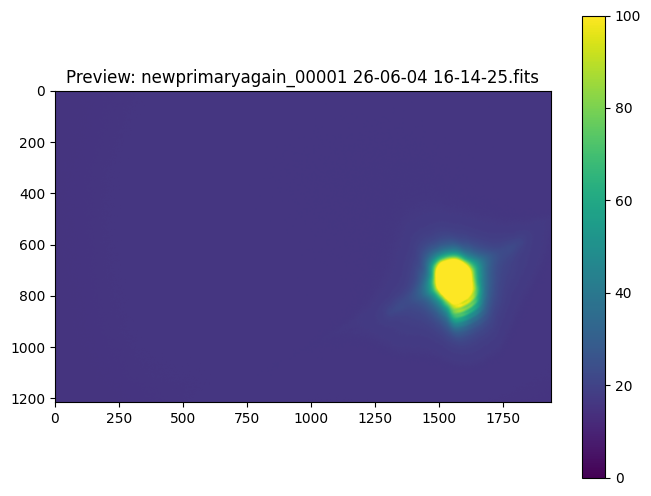

In [17]:
with fits.open(fits_list[0]) as hdul:
    preview = np.flip(hdul[0].data, axis=(0, 1))

plt.figure(figsize=(8, 6))
plt.imshow(preview, cmap="viridis", vmin=0, vmax=100)
plt.title(f"Preview: {os.path.basename(fits_list[0])}")
plt.colorbar()
plt.show()

In [18]:
def gaussian(x, amp, mu, sigma, offset):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + offset

def fit_frame(path):
    """Open one FITS, project to x/y, fit Gaussians. Returns (mu_x, mu_y, sigma_x, sigma_y)."""
    try:
        with fits.open(path) as hdul:
            img = np.flip(hdul[0].data, axis=(0, 1)).astype(np.float64)

        px = np.sum(img, axis=0)
        py = np.sum(img, axis=1)

        popt_x, _ = curve_fit(
            gaussian, np.arange(px.size), px,
            p0=[px.max(), float(px.argmax()), 50.0, float(np.median(px))],
            maxfev=3000,
        )
        popt_y, _ = curve_fit(
            gaussian, np.arange(py.size), py,
            p0=[py.max(), float(py.argmax()), 50.0, float(np.median(py))],
            maxfev=3000,
        )
        return popt_x[1], popt_y[1], abs(popt_x[2]), abs(popt_y[2])
    except Exception:
        return np.nan, np.nan, np.nan, np.nan

print(f"Fitting {len(fits_list)} frames with {WORKERS} workers...")
t0 = time.time()

fit_results = [None] * len(fits_list)
with ThreadPoolExecutor(max_workers=WORKERS) as exe:
    futures = {exe.submit(fit_frame, f): i for i, f in enumerate(fits_list)}
    for n_done, fut in enumerate(as_completed(futures)):
        fit_results[futures[fut]] = fut.result()
        if n_done % 500 == 0:
            elapsed = time.time() - t0
            print(f"  {n_done}/{len(fits_list)}  ({n_done / max(elapsed, 1e-9):.0f} files/s)")

arr      = np.array(fit_results, dtype=float)
mus_x    = arr[:, 0]
mus_y    = arr[:, 1]
sigmas_x = arr[:, 2]
sigmas_y = arr[:, 3]
print(f"Done in {time.time() - t0:.1f}s")

Fitting 7163 frames with 16 workers...
  0/7163  (0 files/s)
  500/7163  (158 files/s)
  1000/7163  (152 files/s)
  1500/7163  (151 files/s)
  2000/7163  (150 files/s)
  2500/7163  (151 files/s)
  3000/7163  (151 files/s)
  3500/7163  (152 files/s)
  4000/7163  (152 files/s)
  4500/7163  (152 files/s)
  5000/7163  (151 files/s)
  5500/7163  (149 files/s)
  6000/7163  (148 files/s)
  6500/7163  (148 files/s)
  7000/7163  (148 files/s)
Done in 48.3s


In [19]:
FWHM_FACTOR = 2.0 * np.sqrt(2.0 * np.log(2.0))   # ~2.355

fwhm_x = sigmas_x * FWHM_FACTOR
fwhm_y = sigmas_y * FWHM_FACTOR

mask = (
    np.isfinite(mus_x) & np.isfinite(mus_y) &
    np.isfinite(fwhm_x) & np.isfinite(fwhm_y) &
    (fwhm_x > FWHM_MIN) & (fwhm_x < FWHM_MAX) &
    (fwhm_y > FWHM_MIN) & (fwhm_y < FWHM_MAX)
)

mus_x_f  = mus_x[mask]
mus_y_f  = mus_y[mask]
fwhm_x_f = fwhm_x[mask]
fwhm_y_f = fwhm_y[mask]

mu_x_rel = mus_x_f - mus_x_f[0]
mu_y_rel = mus_y_f - mus_y_f[0]
frames   = np.arange(len(mu_x_rel))

print(f"{mask.sum()} / {len(mask)} frames passed filter")

7163 / 7163 frames passed filter


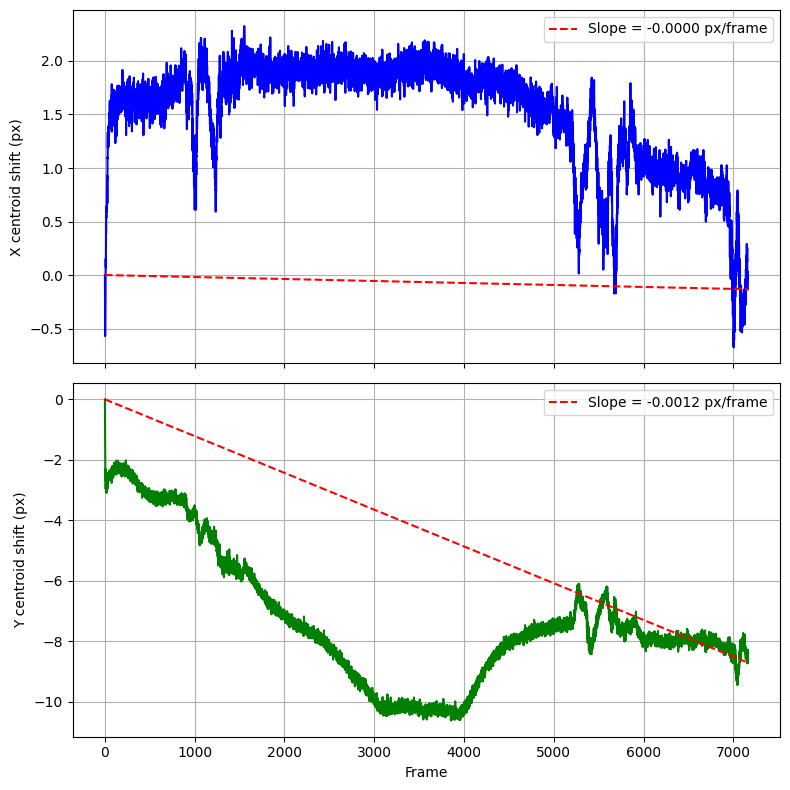

In [20]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(frames, mu_x_rel, color="blue")
axs[0].set_ylabel("X centroid shift (px)")
axs[0].grid(True)
slope_x = (mu_x_rel[-1] - mu_x_rel[0]) / max(int(frames[-1] - frames[0]), 1)
axs[0].plot([frames[0], frames[-1]], [mu_x_rel[0], mu_x_rel[-1]], "r--",
            label=f"Slope = {slope_x:.4f} px/frame")
axs[0].legend()

axs[1].plot(frames, mu_y_rel, color="green")
axs[1].set_xlabel("Frame")
axs[1].set_ylabel("Y centroid shift (px)")
axs[1].grid(True)
slope_y = (mu_y_rel[-1] - mu_y_rel[0]) / max(int(frames[-1] - frames[0]), 1)
axs[1].plot([frames[0], frames[-1]], [mu_y_rel[0], mu_y_rel[-1]], "r--",
            label=f"Slope = {slope_y:.4f} px/frame")
axs[1].legend()

plt.tight_layout()
plt.show()
fig.savefig(output_dir / (foldername + "_position.png"), dpi=150, bbox_inches="tight")

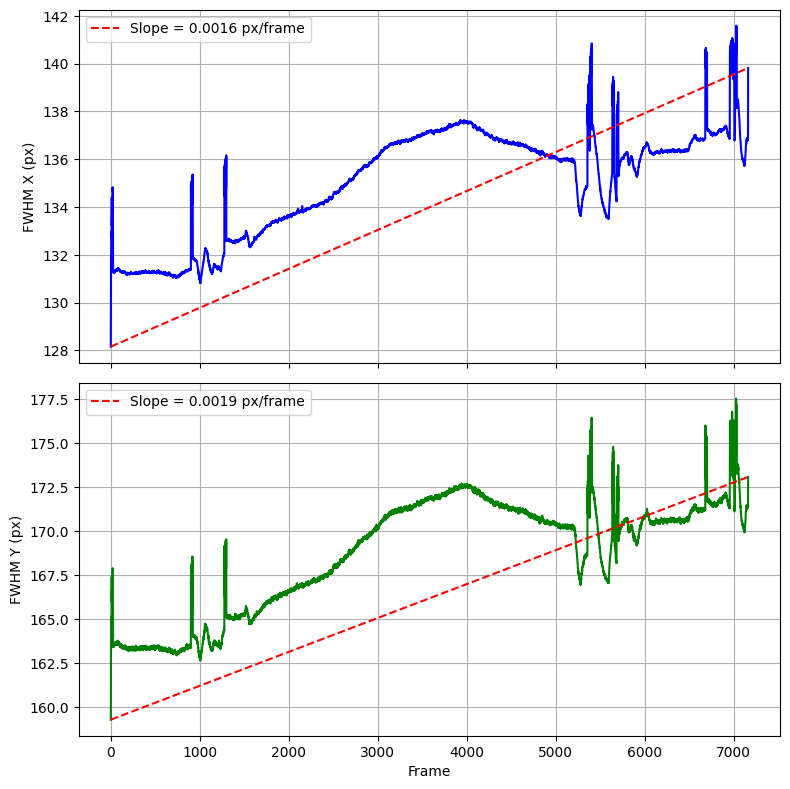

In [21]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axs[0].plot(frames, fwhm_x_f, color="blue")
axs[0].set_ylabel("FWHM X (px)")
axs[0].grid(True)
slope_fx = (fwhm_x_f[-1] - fwhm_x_f[0]) / max(int(frames[-1] - frames[0]), 1)
axs[0].plot([frames[0], frames[-1]], [fwhm_x_f[0], fwhm_x_f[-1]], "r--",
            label=f"Slope = {slope_fx:.4f} px/frame")
axs[0].legend()

axs[1].plot(frames, fwhm_y_f, color="green")
axs[1].set_xlabel("Frame")
axs[1].set_ylabel("FWHM Y (px)")
axs[1].grid(True)
slope_fy = (fwhm_y_f[-1] - fwhm_y_f[0]) / max(int(frames[-1] - frames[0]), 1)
axs[1].plot([frames[0], frames[-1]], [fwhm_y_f[0], fwhm_y_f[-1]], "r--",
            label=f"Slope = {slope_fy:.4f} px/frame")
axs[1].legend()

plt.tight_layout()
plt.show()
fig.savefig(output_dir / (foldername + "_FWHM.png"), dpi=150, bbox_inches="tight")

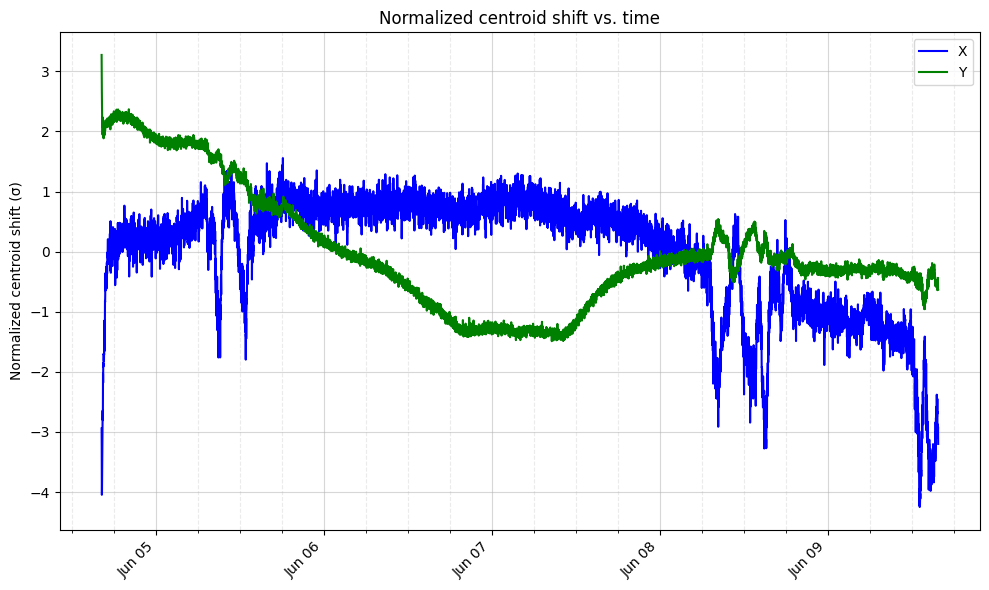

In [22]:
import matplotlib.dates as mdates

# df_times is unfiltered (same length as fits_list); select rows where mask is True
times = pd.to_datetime(df_times["Creation Date"].values[mask])

x_norm = (mu_x_rel - np.mean(mu_x_rel)) / np.std(mu_x_rel)
y_norm = (mu_y_rel - np.mean(mu_y_rel)) / np.std(mu_y_rel)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(times, x_norm, color="blue", label="X")
ax.plot(times, y_norm, color="green", label="Y")

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))

ax.grid(which="major", linestyle="-", alpha=0.5)
ax.grid(which="minor", linestyle="--", alpha=0.25)

for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment("right")

ax.set_ylabel("Normalized centroid shift (σ)")
ax.set_title("Normalized centroid shift vs. time")
ax.legend()

plt.tight_layout()
plt.show()
fig.savefig(output_dir / (foldername + "_normalized_position.png"), dpi=150, bbox_inches="tight")

In [23]:
PIXEL_SCALE = 0.15   # arcsec / px

summary = {
    "filename":           foldername,
    "total frames":       len(fits_list),
    "good frames":        int(mask.sum()),
    "start time":         os.path.basename(fits_list[0])[-22:-5],
    "stop time":          os.path.basename(fits_list[-1])[-22:-5],
    "notes":              notes,
    "frame interval (s)": 60,
    "x position (px)":   float(np.mean(mu_x_rel)),
    "x pos std (px)":    float(np.std(mu_x_rel)),
    "y position (px)":   float(np.mean(mu_y_rel)),
    "y pos std (px)":    float(np.std(mu_y_rel)),
    "x position (as)":   float(np.mean(mu_x_rel) * PIXEL_SCALE),
    "x pos std (as)":    float(np.std(mu_x_rel)  * PIXEL_SCALE),
    "y position (as)":   float(np.mean(mu_y_rel) * PIXEL_SCALE),
    "y pos std (as)":    float(np.std(mu_y_rel)  * PIXEL_SCALE),
    "FWHM x (px)":       float(np.mean(fwhm_x_f)),
    "FWHM x std (px)":   float(np.std(fwhm_x_f)),
    "FWHM y (px)":       float(np.mean(fwhm_y_f)),
    "FWHM y std (px)":   float(np.std(fwhm_y_f)),
}
print(summary)
pd.DataFrame([summary]).to_csv(
    output_dir / (foldername + "_summary.csv"), index=False
)

{'filename': 'newprimaryagain', 'total frames': 7163, 'good frames': 7163, 'start time': '26-06-04 16-14-25', 'stop time': '26-06-09 15-46-50', 'notes': 'second primary test', 'frame interval (s)': 60, 'x position (px)': 1.5212550513364178, 'x pos std (px)': 0.5172054274088536, 'y position (px)': -7.302078434185402, 'y pos std (px)': 2.2316209553327395, 'x position (as)': 0.22818825770046267, 'x pos std (as)': 0.07758081411132803, 'y position (as)': -1.0953117651278104, 'y pos std (as)': 0.3347431432999109, 'FWHM x (px)': 135.05622370206396, 'FWHM x std (px)': 2.228099219378908, 'FWHM y (px)': 168.78164903472913, 'FWHM y std (px)': 3.2005556634177985}


In [24]:
video_indices = np.arange(0, len(fits_list), N_SKIP)
n_frames      = len(video_indices)
output_path   = str(output_dir / (foldername + "_timelapse.mp4"))
DPI           = 100

print(f"Rendering {n_frames} frames @ {VIDEO_FPS} fps  ->  {n_frames / VIDEO_FPS:.1f}s video")

# Sample ~50 frames from the video set to get stable profile axis limits
sample_step = max(1, n_frames // 50)
max_px, max_py = 0.0, 0.0
for idx in video_indices[::sample_step]:
    with fits.open(fits_list[idx]) as hdul:
        img = np.flip(hdul[0].data, axis=(0, 1)).astype(np.float64)
    max_px = max(max_px, float(np.sum(img, axis=0).max()))
    max_py = max(max_py, float(np.sum(img, axis=1).max()))
print(f"Profile limits -- max_x={max_px:.0f}, max_y={max_py:.0f}")

# Build persistent figure (reused every frame, never redisplayed inline)
fig  = plt.figure(figsize=(10, 8), dpi=DPI)
gs   = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.0, hspace=0.0)
ax_img = fig.add_subplot(gs[1, 0])
ax_x   = fig.add_subplot(gs[0, 0], sharex=ax_img)
ax_y   = fig.add_subplot(gs[1, 1], sharey=ax_img)
fig.add_subplot(gs[0, 1]).axis("off")

with fits.open(fits_list[video_indices[0]]) as hdul:
    first_img = np.flip(hdul[0].data, axis=(0, 1)).astype(np.float64)

im      = ax_img.imshow(first_img, cmap="viridis", origin="lower", vmin=0, vmax=100, aspect="auto")
line_x, = ax_x.plot(np.arange(first_img.shape[1]), np.sum(first_img, axis=0), lw=0.8)
line_y, = ax_y.plot(np.sum(first_img, axis=1), np.arange(first_img.shape[0]), lw=0.8)
ts_text = ax_img.text(
    0.02, 0.98, "", transform=ax_img.transAxes,
    color="white", fontsize=11, va="top",
    bbox=dict(facecolor="black", alpha=0.5, edgecolor="none", pad=3),
)

ax_x.set_ylim(0, max_px * 1.05)
ax_y.set_xlim(0, max_py * 1.05)
ax_x.tick_params(labelbottom=False)
ax_y.tick_params(labelleft=False)
ax_x.set_ylabel("counts")
ax_y.set_xlabel("counts")
ax_x.grid(True, alpha=0.4)
ax_y.grid(True, alpha=0.4)
fig.tight_layout()

# Render frames into a temp dir, then hand off to ffmpeg
tmpdir = pathlib.Path(tempfile.mkdtemp())
print(f"Saving PNGs to {tmpdir} ...")
t0 = time.time()

for k, real_idx in enumerate(video_indices):
    with fits.open(fits_list[real_idx]) as hdul:
        img = np.flip(hdul[0].data, axis=(0, 1)).astype(np.float64)

    im.set_array(img)
    line_x.set_ydata(np.sum(img, axis=0))
    line_y.set_xdata(np.sum(img, axis=1))
    label = df_times.iloc[real_idx]["Creation Date"] if real_idx < len(df_times) else ""
    ts_text.set_text(label)

    fig.savefig(tmpdir / f"frame_{k:06d}.png", dpi=DPI)

    if k % 200 == 0:
        elapsed = time.time() - t0
        print(f"  {k}/{n_frames}  ({k / max(elapsed, 1e-9):.1f} fps render)")

plt.close(fig)
render_time = time.time() - t0
print(f"Rendering done in {render_time:.1f}s  ({n_frames / max(render_time, 1e-9):.1f} fps avg)")

cmd = [
    "ffmpeg", "-y",
    "-r", str(VIDEO_FPS),
    "-i", str(tmpdir / "frame_%06d.png"),
    "-vcodec", "libx264", "-pix_fmt", "yuv420p", "-crf", "18",
    output_path,
]
print("Running ffmpeg...")
subprocess.run(cmd, check=True)

shutil.rmtree(tmpdir)
print(f"Saved: {output_path}  (total {time.time() - t0:.1f}s)")

Rendering 1791 frames @ 24 fps  ->  74.6s video
Profile limits -- max_x=61035, max_y=64525
Saving PNGs to C:\Users\jad507\AppData\Local\Temp\tmpdapp3kmt ...
  0/1791  (0.0 fps render)
  200/1791  (3.3 fps render)
  400/1791  (3.4 fps render)
  600/1791  (3.4 fps render)
  800/1791  (3.4 fps render)
  1000/1791  (3.4 fps render)
  1200/1791  (3.4 fps render)
  1400/1791  (3.4 fps render)
  1600/1791  (3.4 fps render)
Rendering done in 530.3s  (3.4 fps avg)
Running ffmpeg...
Saved: C:\Users\jad507\OneDrive - The Pennsylvania State University\Pictures\Reverse Telescope Test\20260420_data\zoeysecondarygenie\run2\newprimaryagain_timelapse.mp4  (total 552.0s)
